   student_id  age  gender  study_hours  math_score  english_score  \
0           1   14    Male            6          80             99   
1           2   14  Female            1          59             87   
2           3   16  Female            5          80             97   
3           4   18    Male            6          79             68   
4           5   14    Male            6          58             80   

   science_score  attendance  final_score  
0             87          71        88.67  
1             71          84        72.33  
2             60          69        79.00  
3             56          88        67.67  
4             51          94        63.00  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   student_id     500 non-null    int64  
 1   age            500 non-null    int64  
 2   gender         500 non-null   

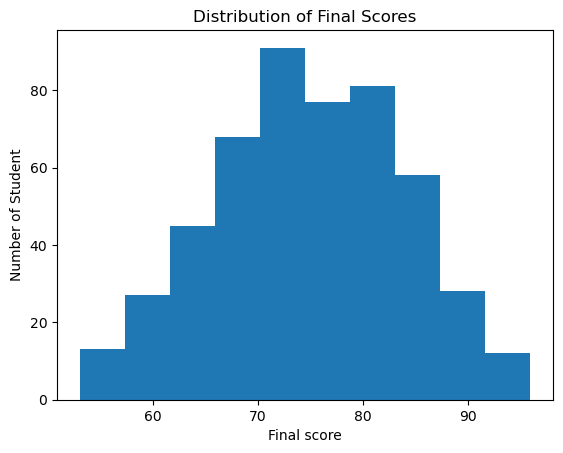

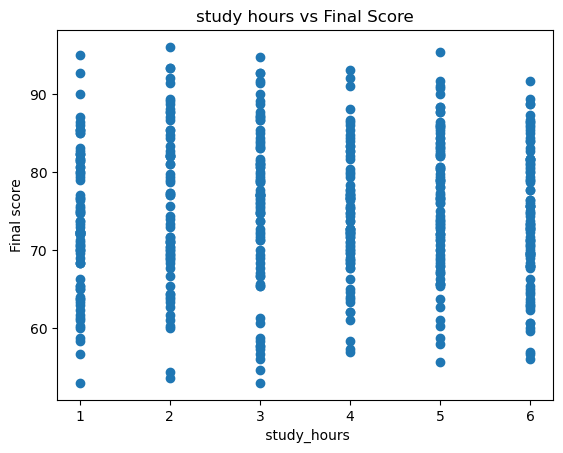

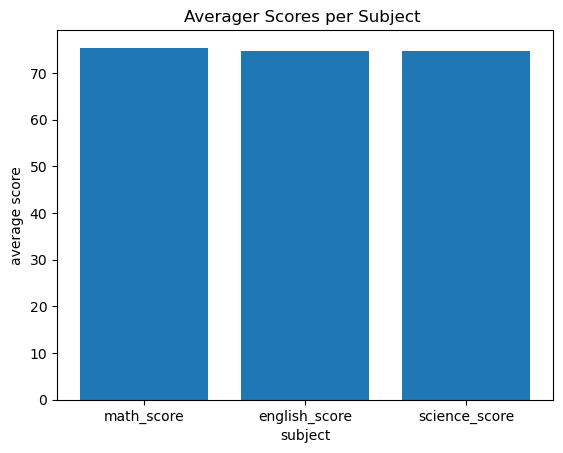

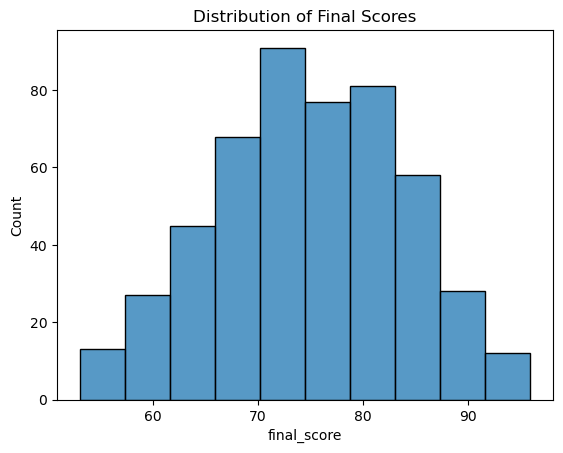

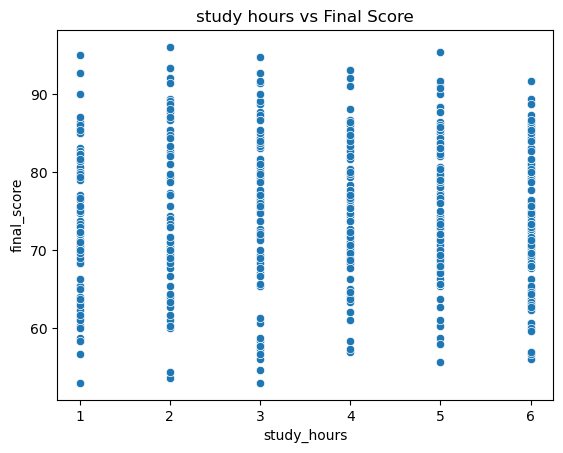

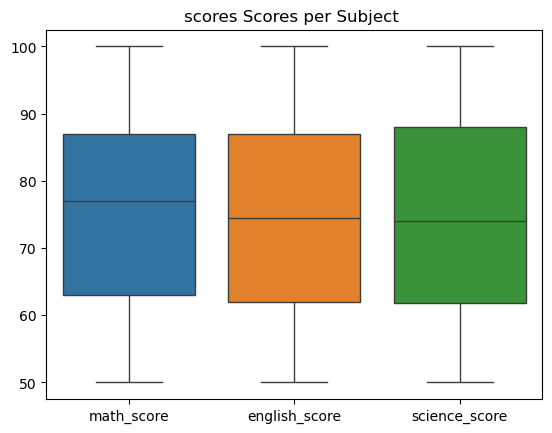

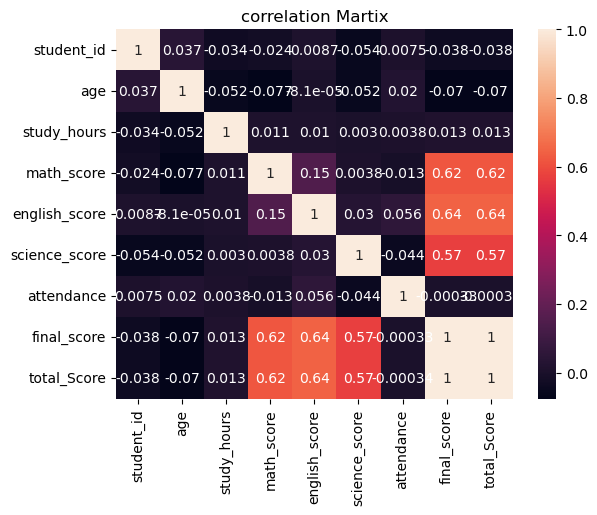

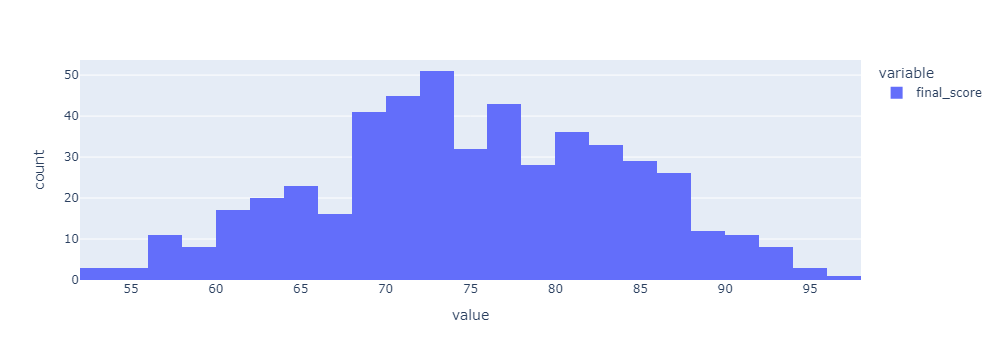

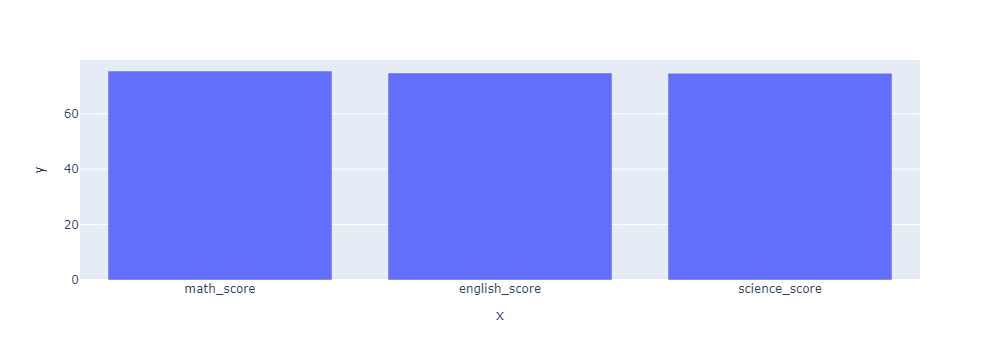

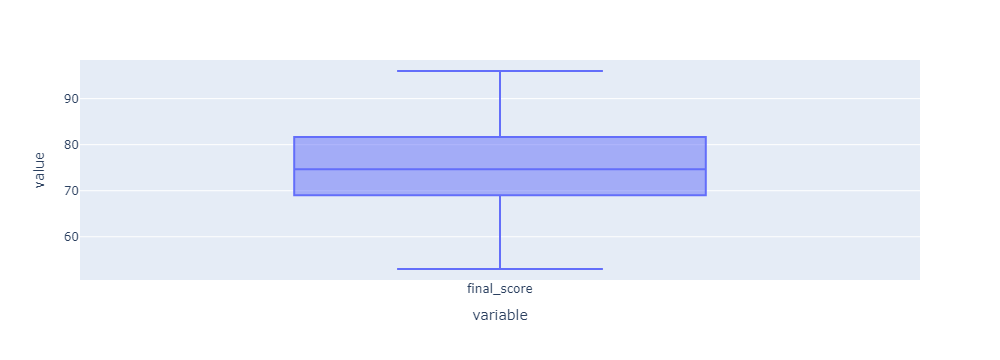

[75.20615373 75.37331423 75.41274923 75.34921421 75.33387923 75.09486076
 75.30737074 75.07601976 75.13955478 75.06835227]
                            OLS Regression Results                            
Dep. Variable:            final_score   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.004
Method:                 Least Squares   F-statistic:                   0.04356
Date:                Wed, 11 Mar 2026   Prob (F-statistic):              0.957
Time:                        11:16:18   Log-Likelihood:                -1806.1
No. Observations:                 500   AIC:                             3618.
Df Residuals:                     497   BIC:                             3631.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm
data = pd.read_excel("student_performance_analysis.xlsx")
print(data.head())
print(data.info())
print(data.describe())
print(data[['math_score' ,'english_score','science_score']].mean())
top_Student = data['final_score'].max()
print("top student",top_Student)
print("mean study hours")
data['study_hours'].mean()
print("sara")
correlation = data.select_dtypes(include='number').corr()
print(correlation)
high_Study = [data['study_hours'] > 4]
print(high_Study)
top_students = data.sort_values(by='final_score' ,ascending =False)
print(top_students.head(10))
data['total_Score'] = data['math_score' ] + data['english_score'] + data['science_score']
print(data.head())
data['Status']=data['final_score'].apply(lambda x: 'pass' if x>=50 else 'fail')
print(data.head())
scores = np.array(data['final_score'])
new_scores = scores + 5
print(new_scores)
mean_scores =np.mean(scores)
Std_scores=np.std(scores)
print("averger" ,mean_scores)
print("std" ,Std_scores)
subjects = np.array(data[['math_score' ,'english_score','science_score']])
print(subjects)
avg_per_Student = np.mean(subjects,axis=1)
print(avg_per_Student)
avg_per_Subject = np.mean(subjects,axis=0)
print(avg_per_Subject)
z_scores =(scores-np.mean(scores)) / np.std(scores)
print(z_scores)
random_scores = np.random.randint(50,100,20)
print(random_scores)
plt.hist(data['final_score'])
plt.title("Distribution of Final Scores")
plt.xlabel("Final score")
plt.ylabel("Number of Student")
plt.show()
plt.scatter(data['study_hours'],data['final_score'])
plt.title("study hours vs Final Score")
plt.xlabel(" study_hours")
plt.ylabel("Final score")
plt.show()
subject = data[['math_score' ,'english_score','science_score']].mean()
plt.bar(subject.index ,subject.values)
plt.title("Averager Scores per Subject ")
plt.xlabel("subject")
plt.ylabel("average score")
plt.show()
sns.histplot(data['final_score'],bins=10)
plt.title("Distribution of Final Scores")
plt.show()
sns.scatterplot(x=data['study_hours'],y=data['final_score'])
plt.title("study hours vs Final Score")
plt.show()
sns.boxplot(data=data[['math_score' ,'english_score','science_score']])
plt.title("scores Scores per Subject ")
plt.show()
correlation = data.select_dtypes(include='number').corr()
sns.heatmap(correlation,annot=True)
plt.title("correlation Martix")
plt.show()
fig = px.histogram(data,x=['final_score'])
fig.show()
subject = data[['math_score' ,'english_score','science_score']].mean()
fig = px.bar(x=subject.index ,y=subject.values)
fig.show()
fig = px.box(data,y=['final_score'])
fig.show() 

# اختيار المتغيرات
X = data[['study_hours','attendance']]
y = data['final_score']

# تقسيم البيانات للتدريب والاختبار
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# إنشاء النموذج
model = LinearRegression()

# تدريب النموذج
model.fit(X_train, y_train)

# التوقع
predictions = model.predict(X_test)
print(predictions[:10])

# اختيار المتغيرات
X = data[['study_hours','attendance']]
y = data['final_score']

# إضافة ثابت للنموذج
X = sm.add_constant(X)

# إنشاء نموذج الانحدار
model = sm.OLS(y, X).fit()

# عرض النتائج
print(model.summary())
